# MNIST/CIFAR10 with 10-class output
Forked from `multihead.ipynb` on July 1.
Incorporates the expression for two tasks but with the correct GP expression.

In [100]:
import numpy as np
import tqdm, utils, theory, pickle, cluster_utils, data, sys, torch
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

def two_task_predictor(x, train_x1, train_x2, y1, y2, lambda_val, depth, sigma, new_term=True):

    lambda_tilde = lambda_val / (lambda_val + sigma**-2)
    var_w1 = sigma**2
    var_w2 = lambda_tilde**2 * var_w1 + 1 / (lambda_val + sigma**-2)

    def k_2_diff(x, x_prime):
        return theory.arccos_kernel_deep(x, x_prime,
                                         var1=var_w2,
                                         var2=var_w2,
                                         covar=lambda_tilde**2 * var_w1, depth=depth)

    def k1(x, x_prime):
        return theory.arccos_kernel_deep(x, x_prime,
                                         var1=var_w1, depth=depth)

    def k2(x, x_prime):
        return theory.arccos_kernel_deep(x, x_prime,
                                         var1=var_w2, depth=depth)

    def k21(x, x_prime):
        return theory.arccos_kernel_deep(x, x_prime,
                                         var1=var_w2, var2=var_w1, covar=lambda_tilde*var_w1, depth=depth)

    # def diff_kernel(x, x_prime):
    #     prod = x @ x_prime.T
    #     cos_mat = prod / torch.norm(x[0])**2
    #     theta = torch.arccos(torch.clamp(cos_mat, -1, 1))
    #     return lambda_tilde**2 * sigma**2 / (2 * torch.pi) / x.shape[1] * prod * (torch.pi - theta)

    def diff_kernel(x, x_prime):
        # the numerical implementation
        return (k2(x, x_prime) - k_2_diff(x, x_prime)) * lambda_tilde * lambda_val * var_w1

    # print('diff', torch.norm((k2(x1, x2) - k_2_diff(x1, x2))) * lambda_tilde * lambda_val * sigma**2)
    # print('normalized new term norm', torch.norm(diff_kernel(x1, x2)) / torch.norm(k2(x1, x2)))

    if new_term:
        new_term_factor = 1
    else:
        new_term_factor = 0

    k1_inv = theory.inverse(k1(train_x1, train_x1))

    return (k2(x, train_x2) + new_term_factor * diff_kernel(x, train_x2)) @\
        theory.inverse(k2(train_x2, train_x2) + new_term_factor *  diff_kernel(train_x2, train_x2)) @\
        (y2 - lambda_tilde * k21(train_x2, train_x1) @ k1_inv @ y1) +\
        lambda_tilde * k21(x, train_x1) @ k1_inv @ y1


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [86]:
task1_te_with = []
task1_te_without = []

DATASET = 'mnist'
P = 1000
P_TEST = 1000
N_TASKS = 2
SIGMA = 0.2
LAMBDA = 1e5
DEPTH = 1
PERMUTATION_RATIOS = np.linspace(0, 1, 10)
print('lambda tilde', LAMBDA / (LAMBDA + SIGMA**2))

for perm in tqdm.tqdm(PERMUTATION_RATIOS):
    torch.manual_seed(1)
    seq_of_train_x, seq_of_test_x, seq_of_train_y_digit, seq_of_test_y_digit = \
        data.prepare_sequential_dataset(N_TASKS, P, P_TEST, dataset_name=DATASET,
                                        resample=False,
                                        permutation=perm, data_path=None, n_epochs=1,
                                        interpolate=False)

    # n_tasks * P * n_heads * 1
    seq_of_train_y_onehot =\
        torch.stack([data.digit_to_onehot(digit) for digit in seq_of_train_y_digit])
    seq_of_test_y_onehot =\
        torch.stack([data.digit_to_onehot(digit) for digit in seq_of_test_y_digit])

    x1 = seq_of_train_x[0].double()
    x2 = seq_of_train_x[1].double()
    x1_test = seq_of_test_x[0].double()
    x2_test = seq_of_test_x[1].double()
    seq_of_train_y_onehot = seq_of_train_y_onehot.double()
    target_y = seq_of_test_y_onehot[0].double()


    # plt.figure()
    test_loss_task_1 = 0
    for head_ind in range(10):
        test_pred = two_task_predictor(x1_test, x1, x2,
                                       seq_of_train_y_onehot[0, :, head_ind],
                                       seq_of_train_y_onehot[1, :, head_ind],
                                       lambda_val=LAMBDA, depth=DEPTH, new_term=True, sigma=SIGMA)
        test_loss_task_1 += torch.mean((test_pred.flatten() - target_y[:, head_ind].flatten())**2) / 10

    # print(test_loss_task_1)
    # plt.scatter(lamb, test_loss_task_1, color='k')
    # print('with new term', test_loss_task_1)
    task1_te_with.append(test_loss_task_1)

    test_loss_task_1 = 0
    for head_ind in range(10):
        test_pred = two_task_predictor(x1_test, x1, x2,
                                       seq_of_train_y_onehot[0, :, head_ind],
                                       seq_of_train_y_onehot[1, :, head_ind],
                                       lambda_val=LAMBDA, depth=DEPTH, new_term=False, sigma=SIGMA)
        test_loss_task_1 += torch.mean((test_pred.flatten() - target_y[:, head_ind].flatten())**2) / 10
    # plt.scatter(lamb, test_loss_task_1, color='b')
    # print('without new term', test_loss_task_1)
    task1_te_without.append(test_loss_task_1)

    # single_seed_train_accuracy, single_seed_test_accuracy, single_seed_train_loss, single_seed_test_loss = \
    #     data.get_multihead_accuracy(seq_of_train_x=seq_of_train_x, seq_of_test_x=seq_of_test_x,
    #                                 seq_of_train_y_digit=seq_of_train_y_digit, seq_of_test_y_digit=seq_of_test_y_digit,
    #                                 sigma=sigma, lamb=lamb,
    #                                 fixed_w=False, depth=depth,
    #                                 write_fn=None, tqdm_disable=True)
    # plt.scatter(depth, single_seed_test_loss[0, 1], color='r')
    # print(single_seed_test_loss[0, 1])
# plt.xscale('log')

lambda tilde 0.9999996000001601


  0%|          | 0/10 [00:00<?, ?it/s]/Users/haozheshan/Dropbox/codes/gp_continual_learning/data.py:204: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(dataset.targets).float()
/Users/haozheshan/Dropbox/codes/gp_continual_learning/theory.py:325: UserWarning: arccosine kernel computation is assuming that all inputs have the same norm.
  warnings.warn('arccosine kernel computation is assuming that all inputs have the same norm.')
100%|██████████| 10/10 [00:25<00:00,  2.55s/it]


# Plot forgetting as a function of permutation, with or without the new terms

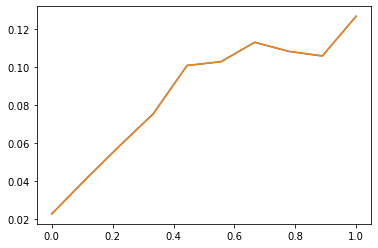

In [85]:
plt.figure()
plt.plot(np.linspace(0, 1, 10), np.array(task1_te_with))
plt.plot(np.linspace(0, 1, 10), task1_te_without)

# Different lambda

In [79]:
task1_te_with = []
task1_te_without = []

DATASET = 'mnist'
P = 1000
P_TEST = 1000
N_TASKS = 2
SIGMA = 0.2
DEPTH = 1
PERM = 1
LAMBDAs = 10**(np.arange(9))

for _lambda in tqdm.tqdm(LAMBDAs):
    torch.manual_seed(1)
    seq_of_train_x, seq_of_test_x, seq_of_train_y_digit, seq_of_test_y_digit = \
        data.prepare_sequential_dataset(N_TASKS, P, P_TEST, dataset_name=DATASET,
                                        resample=False,
                                        permutation=1, data_path=None, n_epochs=1,
                                        interpolate=False)

    # n_tasks * P * n_heads * 1
    seq_of_train_y_onehot =\
        torch.stack([data.digit_to_onehot(digit) for digit in seq_of_train_y_digit])
    seq_of_test_y_onehot =\
        torch.stack([data.digit_to_onehot(digit) for digit in seq_of_test_y_digit])

    x1 = seq_of_train_x[0].double()
    x2 = seq_of_train_x[1].double()
    x1_test = seq_of_test_x[0].double()
    x2_test = seq_of_test_x[1].double()
    seq_of_train_y_onehot = seq_of_train_y_onehot.double()
    target_y = seq_of_test_y_onehot[0].double()


    # plt.figure()
    test_loss_task_1 = 0
    for head_ind in range(10):
        test_pred = two_task_predictor(x1_test, x1, x2,
                                       seq_of_train_y_onehot[0, :, head_ind],
                                       seq_of_train_y_onehot[1, :, head_ind],
                                       lambda_val=_lambda, depth=DEPTH, new_term=True, sigma=SIGMA)
        test_loss_task_1 += torch.mean((test_pred.flatten() - target_y[:, head_ind].flatten())**2) / 10

    # print(test_loss_task_1)
    # plt.scatter(lamb, test_loss_task_1, color='k')
    # print('with new term', test_loss_task_1)
    task1_te_with.append(test_loss_task_1)

    test_loss_task_1 = 0
    for head_ind in range(10):
        test_pred = two_task_predictor(x1_test, x1, x2,
                                       seq_of_train_y_onehot[0, :, head_ind],
                                       seq_of_train_y_onehot[1, :, head_ind],
                                       lambda_val=_lambda, depth=DEPTH, new_term=False, sigma=SIGMA)
        test_loss_task_1 += torch.mean((test_pred.flatten() - target_y[:, head_ind].flatten())**2) / 10
    # plt.scatter(lamb, test_loss_task_1, color='b')
    # print('without new term', test_loss_task_1)
    task1_te_without.append(test_loss_task_1)

    # single_seed_train_accuracy, single_seed_test_accuracy, single_seed_train_loss, single_seed_test_loss = \
    #     data.get_multihead_accuracy(seq_of_train_x=seq_of_train_x, seq_of_test_x=seq_of_test_x,
    #                                 seq_of_train_y_digit=seq_of_train_y_digit, seq_of_test_y_digit=seq_of_test_y_digit,
    #                                 sigma=sigma, lamb=lamb,
    #                                 fixed_w=False, depth=depth,
    #                                 write_fn=None, tqdm_disable=True)
    # plt.scatter(depth, single_seed_test_loss[0, 1], color='r')
    # print(single_seed_test_loss[0, 1])
# plt.xscale('log')

  0%|          | 0/9 [00:00<?, ?it/s]/Users/haozheshan/Dropbox/codes/gp_continual_learning/data.py:204: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(dataset.targets).float()
/Users/haozheshan/Dropbox/codes/gp_continual_learning/theory.py:325: UserWarning: arccosine kernel computation is assuming that all inputs have the same norm.
  warnings.warn('arccosine kernel computation is assuming that all inputs have the same norm.')
100%|██████████| 9/9 [00:28<00:00,  3.14s/it]


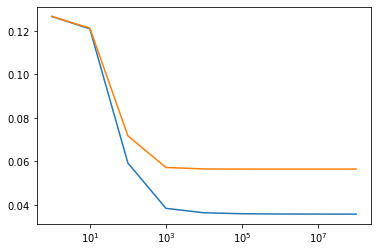

In [80]:
plt.figure()
plt.plot(LAMBDAs, task1_te_with)
plt.plot(LAMBDAs, task1_te_without)
plt.xscale('log')

# Compare Taylor-expanded difference kernel and numerical difference kernel

In [60]:
depth = 10
lambda_val = 1e5
sigma=0.2

lambda_tilde = lambda_val / (lambda_val + sigma**-2)
var_w1 = sigma**2
var_w2 = lambda_tilde**2 * var_w1 + 1 / (lambda_val + sigma**-2)

def k_2_diff(x, x_prime):
    return theory.arccos_kernel_deep(x, x_prime,
                                     var1=var_w2,
                                     var2=var_w2,
                                     covar=lambda_tilde**2 * var_w1, depth=depth)

def k1(x, x_prime):
    return theory.arccos_kernel_deep(x, x_prime,
                                     var1=var_w1, depth=depth)

def k2(x, x_prime):
    return theory.arccos_kernel_deep(x, x_prime,
                                     var1=var_w2, depth=depth)

def k21(x, x_prime):
    return theory.arccos_kernel_deep(x, x_prime,
                                     var1=var_w2, var2=var_w1, covar=lambda_tilde*var_w1, depth=depth)

def diff_kernel(x, x_prime):
    prod = x @ x_prime.T
    cos_mat = prod / torch.norm(x[0])**2
    theta = torch.arccos(torch.clamp(cos_mat, -1, 1))
    return lambda_tilde**2 * sigma**2 / (2 * torch.pi) / x.shape[1] * prod * (torch.pi - theta)

seq_of_train_x, seq_of_test_x, seq_of_train_y_digit, seq_of_test_y_digit = \
        data.prepare_sequential_dataset(2, 100, 100, dataset_name='mnist',
                                        resample=False,
                                        permutation=1, data_path=None, n_epochs=1,
                                        interpolate=False)

x1 = seq_of_train_x[0].float()
x2 = seq_of_train_x[0].float()

diff_numerical = (k2(x1, x2) - k_2_diff(x1, x2)) * lambda_tilde * lambda_val * sigma**2
diff_taylor = diff_kernel(x1, x2)

print(torch.norm(diff_numerical))
# print(torch.norm(diff_taylor))





tensor(3.2617e-15)


(array([ 136.,  410., 1044., 1336., 1408., 1338., 1060.,  834.,  642.,
         472.,  332.,  208.,  186.,  106.,   88.,   68.,   56.,   34.,
          32.,   22.,   16.,   20.,   12.,    4.,   12.,    6.,    4.,
           4.,    8.,    2.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
         100.]),
 array([2.7005659e-17, 2.7689964e-17, 2.8374267e-17, 2.9058570e-17,
        2.9742877e-17, 3.0427180e-17, 3.1111484e-17, 3.1795787e-17,
        3.2480094e-17, 3.3164397e-17, 3.3848701e-17, 3.4533007e-17

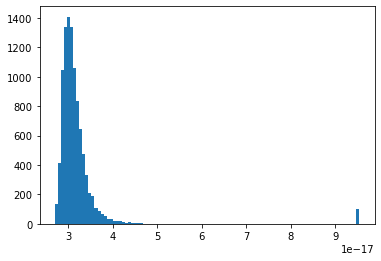

In [61]:
plt.figure()
plt.hist(diff_numerical.flatten().numpy(), bins=100)

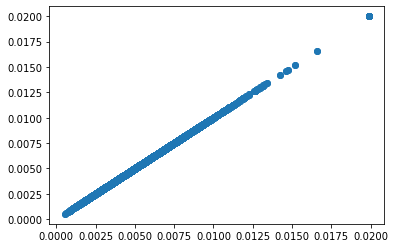

In [54]:
plt.figure()
plt.scatter(diff_numerical.flatten(), diff_taylor.flatten())

In [135]:
task1_te_with = []
task1_te_without = []

DATASET = 'mnist'
P = 1000
P_TEST = 1000
N_TASKS = 2
SIGMA = 0.2
DEPTH = 1
PERM = 1
LAMBDA_VAL = 1e3

torch.manual_seed(1)
seq_of_train_x, seq_of_test_x, seq_of_train_y_digit, seq_of_test_y_digit = \
    data.prepare_sequential_dataset(N_TASKS, P, P_TEST, dataset_name=DATASET,
                                    resample=False,
                                    permutation=1, data_path=None, n_epochs=1,
                                    interpolate=False)

seq_of_train_x = seq_of_train_x.double()
seq_of_test_x = seq_of_test_x.double()



# n_tasks * P * n_heads * 1
seq_of_train_y_onehot =\
    torch.stack([data.digit_to_onehot(digit) for digit in seq_of_train_y_digit])
seq_of_test_y_onehot =\
    torch.stack([data.digit_to_onehot(digit) for digit in seq_of_test_y_digit])

x1 = seq_of_train_x[0]
x2 = seq_of_train_x[1]
x1_test = seq_of_test_x[0]
x2_test = seq_of_test_x[1]
seq_of_train_y_onehot = seq_of_train_y_onehot.double()
target_y = seq_of_test_y_onehot[0].double()


# plt.figure()
test_loss_task_1 = 0
for head_ind in range(10):
    train_pred = two_task_predictor(x1, x1, x2,
                                   seq_of_train_y_onehot[0, :, head_ind],
                                   seq_of_train_y_onehot[1, :, head_ind],
                                   lambda_val=LAMBDA_VAL, depth=DEPTH, new_term=True, sigma=SIGMA)
    test_loss_task_1 += torch.mean((test_pred.flatten() - target_y[:, head_ind].flatten())**2) / 10

train_preds, _ = theory.compute_mean_predictions(seq_of_train_x, seq_of_train_y_onehot[:, :, -1], SIGMA**2, P_TEST, DEPTH,
                             LAMBDA_VAL, seq_of_test_x, fix_weights=False)

single_seed_train_accuracy, single_seed_test_accuracy, single_seed_train_loss, single_seed_test_loss = \
    data.get_multihead_accuracy(seq_of_train_x=seq_of_train_x, seq_of_test_x=seq_of_test_x,
                                seq_of_train_y_digit=seq_of_train_y_digit, seq_of_test_y_digit=seq_of_test_y_digit,
                                sigma=SIGMA, lamb=LAMBDA_VAL,
                                fixed_w=False, depth=DEPTH,
                                write_fn=None)

/Users/haozheshan/Dropbox/codes/gp_continual_learning/data.py:205: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return _shuffle(x, y)
/Users/haozheshan/Dropbox/codes/gp_continual_learning/theory.py:381: UserWarning: arccosine kernel computation is assuming that all inputs have the same norm.
  kappa = covar / math.sqrt(var1 * var2)
/Users/haozheshan/Dropbox/codes/gp_continual_learning/data.py:22: UserWarning: get_multihead_accuracy assumes that there are 10 classes.
  warnings.warn('get_multihead_accuracy assumes that there are 10 classes.')


torch.float64


100%|██████████| 10/10 [00:04<00:00,  2.16it/s]


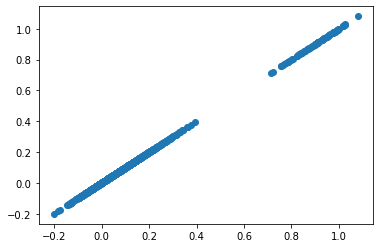

In [136]:
plt.figure()
plt.scatter(train_pred.flatten(), train_preds[0, 1].flatten())

In [129]:
print(single_seed_test_loss[0, 1])

print(test_loss_task_1)

tensor(0.0908)
tensor(0.1495, dtype=torch.float64)


# Naive GP calculation

In [130]:
LAMBDA_TILDE = LAMBDA_VAL / (LAMBDA_VAL + SIGMA**-2)
var_w1 = SIGMA**2
var_w2 = LAMBDA_TILDE**2 * var_w1 + 1 / (LAMBDA_VAL + SIGMA**-2)

DEPTH = 1

def k_2_diff(x, x_prime):
    return theory.arccos_kernel_deep(x, x_prime,
                                     var1=var_w2,
                                     var2=var_w2,
                                     covar=LAMBDA_TILDE**2 * var_w1, depth=DEPTH)

def k1(x, x_prime):
    return theory.arccos_kernel_deep(x, x_prime,
                                     var1=var_w1, depth=DEPTH)

def k2(x, x_prime):
    return theory.arccos_kernel_deep(x, x_prime,
                                     var1=var_w2, depth=DEPTH)

def k21(x, x_prime):
    return theory.arccos_kernel_deep(x, x_prime,
                                     var1=var_w2, var2=var_w1, covar=LAMBDA_TILDE*var_w1, depth=DEPTH)

# def diff_kernel(x, x_prime):
#     prod = x @ x_prime.T
#     cos_mat = prod / torch.norm(x[0])**2
#     theta = torch.arccos(torch.clamp(cos_mat, -1, 1))
#     return lambda_tilde**2 * sigma**2 / (2 * torch.pi) / x.shape[1] * prod * (torch.pi - theta)

def diff_kernel(x, x_prime):
    # the numerical implementation
    return (k2(x, x_prime) - k_2_diff(x, x_prime)) * LAMBDA_TILDE * LAMBDA_VAL * var_w1

# print('diff', torch.norm((k2(x1, x2) - k_2_diff(x1, x2))) * lambda_tilde * lambda_val * sigma**2)
# print('normalized new term norm', torch.norm(diff_kernel(x1, x2)) / torch.norm(k2(x1, x2)))

# if new_term:
#     new_term_factor = 1
# else:
#     new_term_factor = 0
#
# k1_inv = theory.inverse(k1(train_x1, train_x1))

# (k2(x, train_x2) + new_term_factor * diff_kernel(x, train_x2)) @\
#     theory.inverse(k2(train_x2, train_x2) + new_term_factor *  diff_kernel(train_x2, train_x2)) @\
#     (y2 - lambda_tilde * k21(train_x2, train_x1) @ k1_inv @ y1) +\
#     lambda_tilde * k21(x, train_x1) @ k1_inv @ y1

In [131]:
k2_tilde = k2(x1, x1) + diff_kernel(x1, x1)

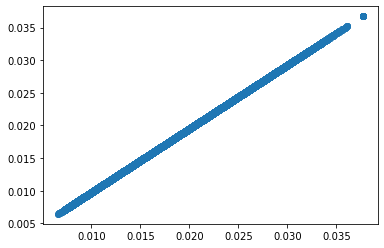

In [134]:
w_vars = theory.compute_W_var(SIGMA**2, LAMBDA_VAL, 2, False)
k2_tilde_new = theory.cross_kernel_new(x1, x1, 1, 1, w_vars, DEPTH, LAMBDA_VAL, SIGMA)

plt.figure()
plt.scatter(k2_tilde.flatten(), k2_tilde_new.flatten())

In [ ]:



#
# single_seed_train_accuracy, single_seed_test_accuracy, single_seed_train_loss, single_seed_test_loss = \
#     data.get_multihead_accuracy(seq_of_train_x=seq_of_train_x, seq_of_test_x=seq_of_test_x,
#                                 seq_of_train_y_digit=seq_of_train_y_digit, seq_of_test_y_digit=seq_of_test_y_digit,
#                                 sigma=args.sigma, lamb=args.lambda_val,
#                                 fixed_w=bool(args.fixed_w), depth=args.depth,
#                                 write_fn=logger.log)
#
# results['test acc'] = single_seed_test_accuracy
# results['train acc'] = single_seed_train_accuracy
# results['train loss'] = single_seed_train_loss
# results['test loss'] = single_seed_test_loss


# training_variances, test_variances, =\
#     theory.compute_predictor_variances(seq_of_train_x=seq_of_train_x,
#                                        w_var=args.sigma**2, P_test=args.P_test,
#                                        lambda_val=args.lambda_val,
#                                        seq_of_test_x=seq_of_test_x,
#                                        fix_weights=args.fixed_w, depth=args.depth)
# mean_training_variances = np.zeros((len(seq_of_train_x), len(seq_of_train_x)))
# for i in range(len(seq_of_train_x)):
#     for j in range(len(seq_of_train_x)):
#         mean_training_variances[i, j] = np.mean(np.diag(training_variances[i, j]))
#
# mean_test_variances = np.zeros((test_variances.shape[0], test_variances.shape[1]))
# for i in range(test_variances.shape[0]):
#     for j in range(test_variances.shape[1]):
#         mean_test_variances[i, j] = np.mean(np.diag(test_variances[i, j]))
#
# results['test var'] = mean_test_variances
# results['train var'] = mean_training_variances

logger.log('starting to compute batch accuracy')
# test accuracy using all the training data in one batch
batch_acc = torch.zeros(args.n_tasks)
batch_loss = torch.zeros(args.n_tasks)
for task_ind in tqdm.trange(10):
    merged_train_x = torch.flip(seq_of_train_x, dims=[0])[:task_ind+1].reshape(-1, seq_of_train_x.shape[-1])
    merged_train_y = torch.flip(seq_of_train_y_digit, dims=[0])[:task_ind+1].flatten()
    merged_test_x = seq_of_test_x[-1]
    merged_test_y = seq_of_test_y_digit[-1]

    batch_acc[task_ind], batch_loss[task_ind] =\
        theory.multihead_one_task_accuracy(train_x=merged_train_x, train_y=merged_train_y,
                                           test_x=merged_test_x, test_y=merged_test_y,
                                           depth=args.depth)

logger.log('finished computing batch accuracy')

if ON_CLUSTER:

    logger.finish(results)
    sys.exit()

/Users/haozheshan/Dropbox/codes/gp_continual_learning/data.py:204: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(dataset.targets).float()


06/30/2022 19:54:24 | Name of this run: BATCH_NAME_0
06/30/2022 19:54:24 | Namespace(f=None, cluster=0, BATCH_NAME='BATCH_NAME', TRIAL_IND=0, P=1000, P_test=1000, n_tasks=2, T=0.0, sigma=0.2, depth=1, seed=1, fixed_w=0, lambda_val=1000.0, dataset='mnist', permutation=1.0, n_epochs=1, resample=1, interpolate=0)
None
06/30/2022 19:54:24 | starting to compute batch accuracy


  0%|          | 0/10 [00:00<?, ?it/s]/Users/haozheshan/Dropbox/codes/gp_continual_learning/theory.py:325: UserWarning: arccosine kernel computation is assuming that all inputs have the same norm.
  warnings.warn('arccosine kernel computation is assuming that all inputs have the same norm.')
 20%|██        | 2/10 [00:00<00:00, 10.54it/s]


IndexError: index 2 is out of bounds for dimension 0 with size 2

In [72]:
for i in range(args.n_tasks):
            seq_of_train_x[i] = seq_of_train_x[i][torch.argsort(seq_of_train_y_digit[i])]

k12 = theory.arccos_kernel_deep(seq_of_train_x[0], seq_of_train_x[1], depth=1, var1=1)
k1 = theory.arccos_kernel_deep(seq_of_train_x[0], seq_of_train_x[0], depth=1, var1=1)
k2 = theory.arccos_kernel_deep(seq_of_train_x[1], seq_of_train_x[1], depth=1, var1=1)

lambda0s = np.linspace(0, 1, 50)

plt.figure()
for _lamb0 in lambda0s:
    mat = k12 @ theory.inverse(k2) @ (torch.eye(args.P) - _lamb0 * k12.T @ theory.inverse(k1)) + torch.eye(args.P) * (_lamb0 - 1)
    plt.scatter(_lamb0, torch.trace(mat.T @ mat / args.P))
plt.show()

tensor(0.8526)

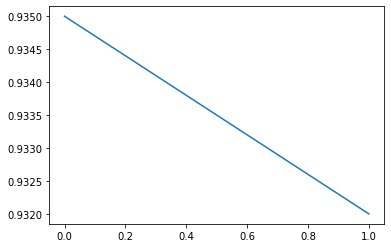

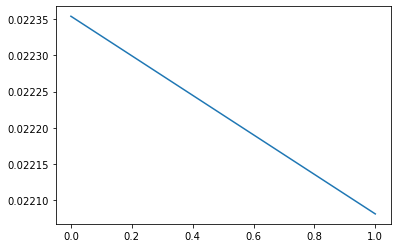

In [16]:
plt.figure()
plt.plot(batch_acc)

plt.figure()
plt.plot(batch_loss)

In [49]:
def tabulate_forgetting(forgetting_matrix, title):
    print(title)
    matrix_for_printing = np.hstack([(np.arange(len(forgetting_matrix)) + 1).reshape(-1, 1), forgetting_matrix.T])
    print(tabulate(matrix_for_printing, headers=['# tasks learnt'] + [f'task{i+1}' for i in range(len(forgetting_matrix))]))

print(f'Permuted MNIST: P={P},P_test={P_test},sigma={sigma},seed:{SEED},lambda={lambda_val},depth={depth}')
tabulate_forgetting(single_seed_train_accuracy, 'training accuracy')
tabulate_forgetting(single_seed_test_accuracy, 'test accuracy')

Permuted MNIST: P=500,P_test=100,sigma=0.2,seed:1,lambda=10000000,depth=1
training accuracy
  # tasks learnt    task1    task2    task3    task4    task5    task6    task7    task8    task9    task10
----------------  -------  -------  -------  -------  -------  -------  -------  -------  -------  --------
               1    1        0.372    0.372    0.28     0.424    0.352    0.352    0.348    0.288     0.248
               2    0.874    1        0.444    0.442    0.514    0.35     0.36     0.304    0.442     0.252
               3    0.818    0.768    1        0.36     0.302    0.292    0.286    0.482    0.358     0.438
               4    0.678    0.756    0.9      1        0.34     0.36     0.422    0.39     0.486     0.434
               5    0.674    0.772    0.758    0.818    1        0.47     0.478    0.464    0.462     0.374
               6    0.628    0.762    0.724    0.688    0.906    1        0.354    0.528    0.53      0.496
               7    0.646    0.822    0.7   

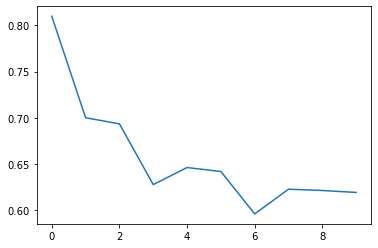

In [50]:
plt.figure()
avg_test_acc_over_tasks = np.zeros(n_tasks)
for i in range(n_tasks):
    avg_test_acc_over_tasks[i] = torch.mean(single_seed_test_accuracy[:i+1, i])
plt.plot(avg_test_acc_over_tasks)

In [27]:
avg_test_variance = np.zeros((n_tasks, n_tasks))  # averaged over data points
for i in range(n_tasks):
    for j in range(n_tasks):
        avg_test_variance[i, j] = np.mean(np.diag(test_variances[i, j]))

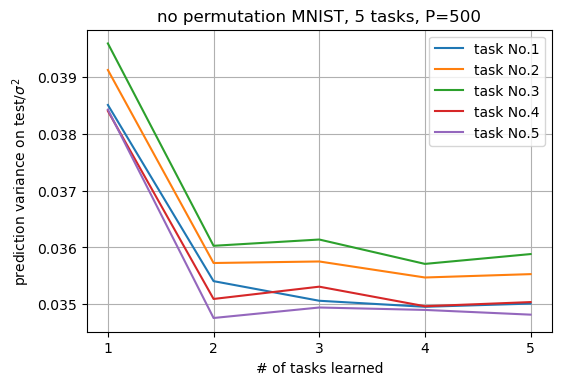

In [28]:


plt.figure(dpi=100)
for task_ind in range(n_tasks):
    plt.plot(np.arange(n_tasks) + 1, avg_test_variance[task_ind] / sigma**2, label=f'task No.{task_ind+1}')
plt.ylabel('prediction variance on test/$\sigma^2$')
plt.title('no permutation MNIST, 5 tasks, P=500')
plt.xlabel('# of tasks learned')
_ = plt.xticks(np.arange(n_tasks) + 1)
plt.legend()
plt.grid()